In [3]:
import pandas as pd 
import seaborn as sns

In [4]:
#Armazenar o caminho do arquivo em uma variável
df = pd.read_csv(r"data\dataset_techshop_vendas.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   data_pedido      800 non-null    object 
 1   categoria        800 non-null    object 
 2   preco_unitario   800 non-null    float64
 3   quantidade       800 non-null    int64  
 4   regiao           800 non-null    object 
 5   canal_marketing  800 non-null    object 
 6   avaliacao        800 non-null    float64
dtypes: float64(2), int64(1), object(4)
memory usage: 43.9+ KB


In [6]:
df = pd.read_csv(r"data\dataset_techshop_vendas.csv", parse_dates=["data_pedido"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   data_pedido      800 non-null    datetime64[ns]
 1   categoria        800 non-null    object        
 2   preco_unitario   800 non-null    float64       
 3   quantidade       800 non-null    int64         
 4   regiao           800 non-null    object        
 5   canal_marketing  800 non-null    object        
 6   avaliacao        800 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 43.9+ KB


In [7]:
#Exibe as colunas em forma de lista
df.columns.to_list() 

['data_pedido',
 'categoria',
 'preco_unitario',
 'quantidade',
 'regiao',
 'canal_marketing',
 'avaliacao']

In [8]:
df.head()

,data_pedido,categoria,preco_unitario,quantidade,regiao,canal_marketing,avaliacao
0,2024-01-01,Acessórios,36.20,1,Sudeste,Instagram,3.3
1,2024-01-01,Acessórios,122.61,5,Sudeste,Orgânico,4.4
2,2024-01-02,Acessórios,151.19,4,Sul,Google Ads,4.6
3,2024-01-03,TVs,3399.16,2,Sudeste,Google Ads,4.1
4,2024-01-04,Smartphones,3180.94,2,Nordeste,Instagram,3.9


In [9]:
df["faturamento"] = df["preco_unitario"] * df["quantidade"]
df.head()

,data_pedido,categoria,preco_unitario,quantidade,regiao,canal_marketing,avaliacao,faturamento
0,2024-01-01,Acessórios,36.20,1,Sudeste,Instagram,3.3,36.20
1,2024-01-01,Acessórios,122.61,5,Sudeste,Orgânico,4.4,613.05
2,2024-01-02,Acessórios,151.19,4,Sul,Google Ads,4.6,604.76
3,2024-01-03,TVs,3399.16,2,Sudeste,Google Ads,4.1,6798.32
4,2024-01-04,Smartphones,3180.94,2,Nordeste,Instagram,3.9,6361.88


In [10]:
df = df[["data_pedido","categoria","preco_unitario","quantidade","regiao","canal_marketing","avaliacao","faturamento"]]
df.head

<bound method NDFrame.head of     data_pedido    categoria  preco_unitario  quantidade    regiao  \
0    2024-01-01   Acessórios           36.20           1   Sudeste   
1    2024-01-01   Acessórios          122.61           5   Sudeste   
2    2024-01-02   Acessórios          151.19           4       Sul   
3    2024-01-03          TVs         3399.16           2   Sudeste   
4    2024-01-04  Smartphones         3180.94           2  Nordeste   
..          ...          ...             ...         ...       ...   
795  2024-12-27        Áudio         1128.44           4       Sul   
796  2024-12-27   Acessórios          209.29           4   Sudeste   
797  2024-12-28    Notebooks         7979.84           2   Sudeste   
798  2024-12-28    Notebooks         4168.01           1  Nordeste   
799  2024-12-28   Acessórios          111.95           1       Sul   

    canal_marketing  avaliacao  faturamento  
0         Instagram        3.3        36.20  
1          Orgânico        4.4       

In [11]:
faturamento_total = df["faturamento"].sum()
print(faturamento_total)

2847624.13


In [12]:
faturamento_formatado = f"{faturamento_total:,.2f}" .replace(",","x").replace("." , ",").replace("x",".")
print(f"O faturamento total é: {faturamento_formatado}")


O faturamento total é: 2.847.624,13


In [13]:
df.loc['total'] = df.sum(numeric_only=True) 
df.tail()


C:\Users\FIC\AppData\Local\Temp\ipykernel_28788\1860766804.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df.loc['total'] = df.sum(numeric_only=True)


,data_pedido,categoria,preco_unitario,quantidade,regiao,canal_marketing,avaliacao,faturamento
796,2024-12-27,Acessórios,209.29,4.0,Sudeste,Google Ads,3.8,837.16
797,2024-12-28,Notebooks,7979.84,2.0,Sudeste,Google Ads,4.4,15959.68
798,2024-12-28,Notebooks,4168.01,1.0,Nordeste,Instagram,4.1,4168.01
799,2024-12-28,Acessórios,111.95,1.0,Sul,Google Ads,4.7,111.95
total,NaT,NaN,1739011.23,1790.0,NaN,NaN,3332.4,2847624.13


In [14]:
df.loc[799, "categoria"] = "Notebooks"
df.tail()

,data_pedido,categoria,preco_unitario,quantidade,regiao,canal_marketing,avaliacao,faturamento
796,2024-12-27,Acessórios,209.29,4.0,Sudeste,Google Ads,3.8,837.16
797,2024-12-28,Notebooks,7979.84,2.0,Sudeste,Google Ads,4.4,15959.68
798,2024-12-28,Notebooks,4168.01,1.0,Nordeste,Instagram,4.1,4168.01
799,2024-12-28,Notebooks,111.95,1.0,Sul,Google Ads,4.7,111.95
total,NaT,NaN,1739011.23,1790.0,NaN,NaN,3332.4,2847624.13


In [15]:
df.loc[799]

data_pedido        2024-12-28 00:00:00
categoria                    Notebooks
preco_unitario                  111.95
quantidade                         1.0
regiao                             Sul
canal_marketing             Google Ads
avaliacao                          4.7
faturamento                     111.95
Name: 799, dtype: object

In [16]:
#filtro pela linha e pela coluna 
df.loc[[1] , "preco_unitario"]

1    122.61
Name: preco_unitario, dtype: float64

In [17]:
#Cria um novo arquivo csv a partir do que você já tem
df.to_csv("dataset_com_total.csv")


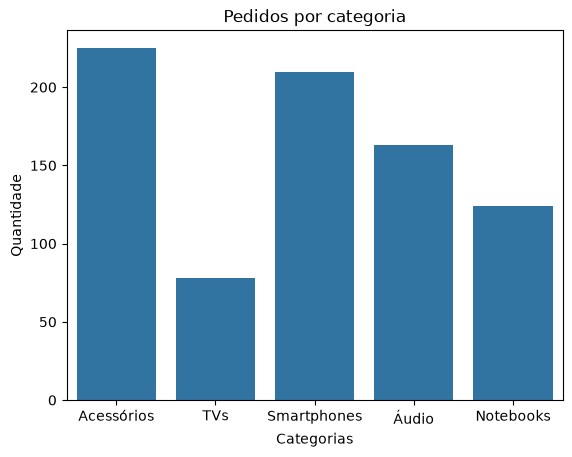

In [18]:
grafico = sns.countplot(data=df, x="categoria");
grafico.set_title("Pedidos por categoria");
grafico.set_xlabel("Categorias");
grafico.set_ylabel("Quantidade");


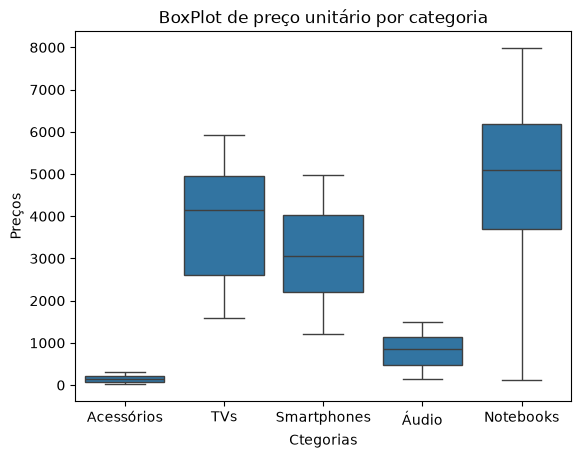

In [19]:
grafico = sns.boxplot(data=df, x="categoria", y="preco_unitario");
grafico.set_title("BoxPlot de preço unitário por categoria");
grafico.set_xlabel("Ctegorias");
grafico.set_ylabel("Preços");

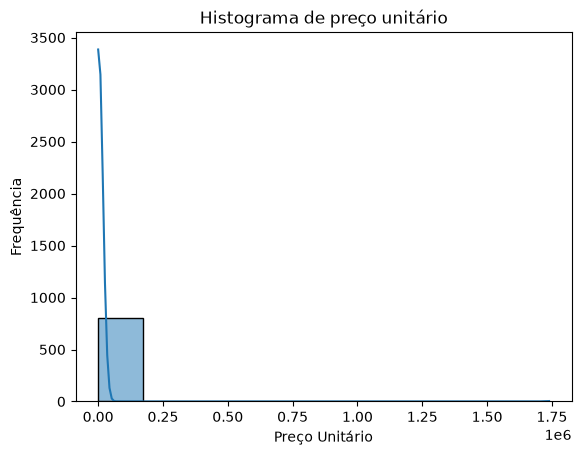

In [20]:
grafico = sns.histplot(data=df, x="preco_unitario", bins=10, kde=True);
grafico.set_title("Histograma de preço unitário");
grafico.set_xlabel("Preço Unitário");
grafico.set_ylabel("Frequência");